# Análisis de viajes en taxi — Chicago (noviembre 2017)

Exploración de la demanda de viajes por compañía y por barrio, y prueba de hipótesis sobre el efecto del clima en la duración de los trayectos. Los datos provienen de consultas SQL sobre la base de datos de viajes de Chicago.

## Datos y carga

In [1]:
import pandas as pd 
from matplotlib import pyplot as plt

In [2]:
# Inspeccionamos estructura y tipos de datos para confirmar que se cargaron correctamente

df_companies = pd.read_csv('../data/project_sql_result_01.csv') 
df_areas = pd.read_csv('../data/project_sql_result_04.csv')

df_companies, df_areas

(                       company_name  trips_amount
 0                         Flash Cab         19558
 1         Taxi Affiliation Services         11422
 2                 Medallion Leasing         10367
 3                        Yellow Cab          9888
 4   Taxi Affiliation Service Yellow          9299
 ..                              ...           ...
 59     4053 - 40193 Adwar H. Nikola             7
 60          2733 - 74600 Benny Jona             7
 61    5874 - 73628 Sergey Cab Corp.             5
 62       2241 - 44667 - Felman Corp             3
 63      3556 - 36214 RC Andrews Cab             2
 
 [64 rows x 2 columns],
    dropoff_location_name  average_trips
 0                   Loop   10727.466667
 1            River North    9523.666667
 2          Streeterville    6664.666667
 3              West Loop    5163.666667
 4                 O'Hare    2546.900000
 ..                   ...            ...
 89       Mount Greenwood       3.137931
 90             Hegewisch       3.

In [3]:
df_companies.info()
df_companies.head()
df_areas.info()
df_areas.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


## Compañías y barrios con más viajes

In [4]:
# Ordenamos los barrios por promedio de viajes y seleccionamos el Top 10

top10 = df_areas.sort_values('average_trips', ascending=False).head(10)
print (top10)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


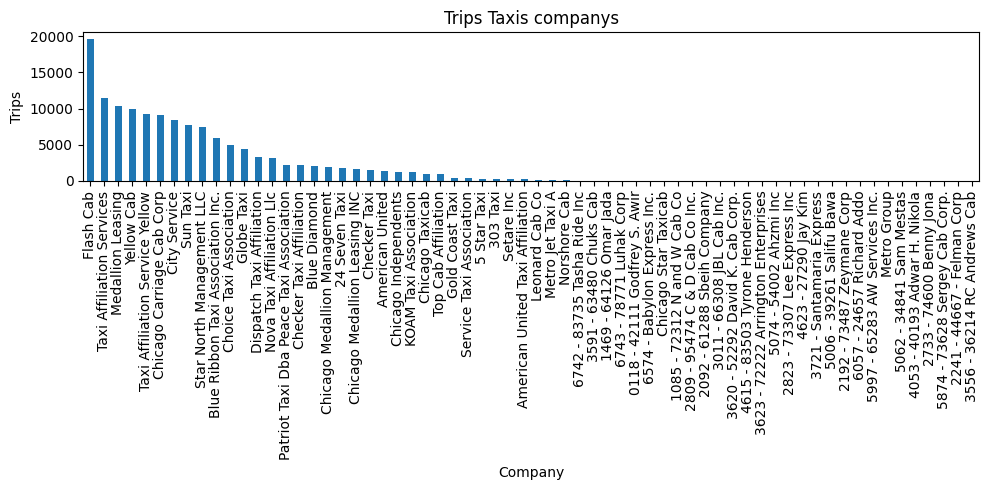

In [5]:
# Visualizamos el volumen de viajes por compañía para identificar las más activas

df_companies.sort_values('trips_amount', ascending=False).plot(
x='company_name',
y='trips_amount',
kind='bar',
figsize=(10,5),
legend=False
)
plt.title('Viajes por compañía de taxi')
plt.ylabel('Viajes')
plt.xlabel('Compañía')
plt.tight_layout()
plt.show()

El volumen de viajes por empresa presenta una distribución desigual. Flash Cab y Taxi Affiliation Services son las empresas con mayor cantidad de viajes, lo que indica una posición superior en el periodo analizado del 15–16 de noviembre. El resto de compañías aparece con cifras mucho menores, lo que muestra un mercado fragmentado debajo de los dos líderes. La distancia entre el primer lugar y las empresas del medio es amplia, lo cual nos demuestra que hay distintos niveles de operación. El orden descendente facilita comparar el peso relativo de cada empresa. En general, este comportamiento refleja concentración operativa en pocas compañías, dentro de dicho periodo.

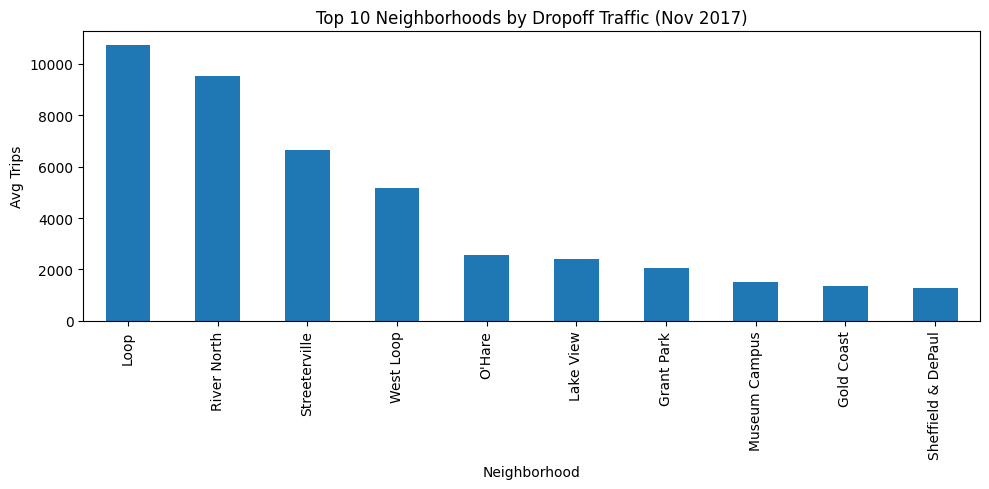

In [6]:
# Visualizamos el Top 10 de barrios donde finalizan más viajes

top10.plot(
    x='dropoff_location_name',
    y='average_trips',
    kind='bar',
    figsize=(10,5),
    legend=False
)
plt.title('Top 10 Neighborhoods by Dropoff Traffic (Nov 2017)')
plt.ylabel('Avg Trips')
plt.xlabel('Neighborhood')
plt.tight_layout()
plt.show()

En noviembre, los barrios con mayor finalización de viajes fueron Loop, River North y Streeterville, seguidos por West Loop y O’Hare. Estos cinco barrios destacan por tener valores considerablemente superiores al resto del Top 10. A partir del sexto lugar, los números disminuyen y la distribución se vuelve más pareja. El orden descendente permite visualizar claramente los niveles de tráfico por barrio. Este resultado muestra que la actividad no está equilibrada entre zonas, sino que se concentra en algunos puntos específicos.Estos barrios absorben la mayor parte de las finalizaciones de viaje del mes analizado.

## Prueba de hipótesis: ¿influye el clima en la duración de los viajes?

**H₀:** la duración promedio de los viajes los sábados con clima *Bad* es igual a la de los sábados con clima *Good* (el clima no influye).

**H₁:** ambas duraciones promedio son diferentes (el clima sí influye).

Nivel de significación: α = 0.05.

In [19]:
import pandas as pd
from scipy import stats

df = pd.read_csv('../data/project_sql_result_07.csv')

df.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [21]:
df['start_ts'] = pd.to_datetime(df['start_ts'])
df.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [22]:
df['weekday'] = df['start_ts'].dt.dayofweek
df['weekday'].value_counts()

5    1068
Name: weekday, dtype: int64

In [23]:
df_sat = df[df['weekday'] == 5]
df_sat.head()

,start_ts,weather_conditions,duration_seconds,weekday
0,2017-11-25 16:00:00,Good,2410.0,5
1,2017-11-25 14:00:00,Good,1920.0,5
2,2017-11-25 12:00:00,Good,1543.0,5
3,2017-11-04 10:00:00,Good,2512.0,5
4,2017-11-11 07:00:00,Good,1440.0,5


In [24]:
df_sat['weather_conditions'].value_counts()

Good    888
Bad     180
Name: weather_conditions, dtype: int64

In [25]:
good = df_sat[df_sat['weather_conditions'] == 'Good']['duration_seconds']
bad  = df_sat[df_sat['weather_conditions'] == 'Bad']['duration_seconds']

good.head(), bad.head()

(0    2410.0
 1    1920.0
 2    1543.0
 3    2512.0
 4    1440.0
 Name: duration_seconds, dtype: float64,
 6     2969.0
 30    1980.0
 34    2460.0
 51    2760.0
 52    2460.0
 Name: duration_seconds, dtype: float64)

In [26]:
good.describe(), bad.describe()

(count     888.000000
 mean     1999.675676
 std       759.198268
 min         0.000000
 25%      1389.750000
 50%      1800.000000
 75%      2460.000000
 max      7440.000000
 Name: duration_seconds, dtype: float64,
 count     180.000000
 mean     2427.205556
 std       721.314138
 min       480.000000
 25%      1962.000000
 50%      2540.000000
 75%      2928.000000
 max      4980.000000
 Name: duration_seconds, dtype: float64)

In [27]:
alpha = 0.05 # nivel de significación

stat, p_value = stats.ttest_ind(good, bad, equal_var=False)

p_value, stat

(6.738994326108734e-12, -7.186034288068629)

In [28]:
print("Media Good:", good.mean())
print("Media Bad:", bad.mean())

Media Good: 1999.6756756756756
Media Bad: 2427.2055555555557


## Conclusión

La prueba t de Welch arroja un **p-valor < 0.05**, por lo que se **rechaza la hipótesis nula**: la duración promedio de los viajes los sábados difiere de forma significativa entre días de buen y mal clima. En la práctica, los días con clima *Bad* presentan trayectos más largos, lo que sugiere que las condiciones meteorológicas afectan los tiempos de viaje.

Además, **Flash Cab** y **Taxi Affiliation Services** son las compañías con más viajes, y **Loop**, **River North** y **Streeterville** los barrios con mayor número de destinos.